In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from torch.amp import autocast, GradScaler

ImageFile.LOAD_TRUNCATED_IMAGES = True  # Avoid issues with corrupted images

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", DEVICE)



✅ Using device: cuda


In [2]:
df_path = r"C:\Users\project\Music\project\TuberculosisML\Database"  # <-- UPDATE this path

valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
image_paths = []
labels = []

for root, _, files in os.walk(df_path):
    for file in files:
        if any(file.lower().endswith(ext) for ext in valid_extensions):
            full_path = os.path.join(root, file)
            label = os.path.basename(os.path.dirname(full_path))
            image_paths.append(full_path)
            labels.append(label)

df = pd.DataFrame({"image_path": image_paths, "classes": labels})
print("✅ Total images found:", len(df))
print(df['classes'].value_counts())
 

✅ Total images found: 7208
classes
Normal          4014
Tuberculosis    3194
Name: count, dtype: int64


In [3]:
# Training transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
class TBImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.df['label_idx'] = self.label_encoder.fit_transform(self.df['classes'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label_idx']
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            image = self.transform(image)
        return image, label




In [5]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['classes'], random_state=42)

train_dataset = TBImageDataset(train_df, transform=train_transform)
val_dataset = TBImageDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)


In [6]:
# Optional: handle class imbalance
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(df['classes']),
                                     y=df['classes'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)


In [7]:
model = models.efficientnet_v2_s(weights="DEFAULT")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier head
num_classes = len(train_dataset.label_encoder.classes_)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(DEVICE)



In [8]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler(device=DEVICE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [ ]:
EPOCHS = 15  # Increase if needed

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch}/{EPOCHS}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with autocast(device_type=DEVICE.type):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += imgs.size(0)

        loop.set_postfix({
            "Loss": running_loss / running_total,
            "Acc": 100 * running_correct / running_total
        })

    print(f"✅ Epoch {epoch} complete - Loss: {running_loss / running_total:.4f}, "
          f"Accuracy: {100 * running_correct / running_total:.2f}%")

    scheduler.step()



In [10]:
EPOCHS = 15  # Increase if needed

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch}/{EPOCHS}]")

    for imgs, labels in loop:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).long()  # ✅ Fix here

        optimizer.zero_grad()
        with autocast(device_type=DEVICE.type):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += imgs.size(0)

        loop.set_postfix({
            "Loss": running_loss / running_total,
            "Acc": 100 * running_correct / running_total
        })

    print(f"✅ Epoch {epoch} complete - Loss: {running_loss / running_total:.4f}, "
          f"Accuracy: {100 * running_correct / running_total:.2f}%")

    scheduler.step()



Epoch [1/15]: 100%|████████████████████████████████████████████| 181/181 [02:47<00:00,  1.08it/s, Loss=0.615, Acc=71.3]


✅ Epoch 1 complete - Loss: 0.6154, Accuracy: 71.26%


Epoch [2/15]: 100%|████████████████████████████████████████████| 181/181 [02:30<00:00,  1.20it/s, Loss=0.496, Acc=85.3]


✅ Epoch 2 complete - Loss: 0.4959, Accuracy: 85.31%


Epoch [3/15]: 100%|████████████████████████████████████████████| 181/181 [02:25<00:00,  1.25it/s, Loss=0.433, Acc=87.2]


...

✅ Epoch 13 complete - Loss: 0.3126, Accuracy: 88.81%


Epoch [14/15]: 100%|███████████████████████████████████████████| 181/181 [02:19<00:00,  1.29it/s, Loss=0.308, Acc=89.2]


✅ Epoch 14 complete - Loss: 0.3082, Accuracy: 89.18%


Epoch [15/15]: 100%|███████████████████████████████████████████| 181/181 [02:17<00:00,  1.32it/s, Loss=0.308, Acc=89.5]


✅ Epoch 15 complete - Loss: 0.3081, Accuracy: 89.51%


In [13]:
epoch_losses = []
epoch_accuracies = []
epoch_f1_scores = []


In [14]:
    # Calculate epoch-level metrics
    epoch_loss = running_loss / running_total
    epoch_acc = 100 * running_correct / running_total

    # Collect predictions and labels for F1 Score
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in train_loader:  # Optional: use val_loader instead
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE).long()
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')  # or 'weighted'

    # Save metrics
    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_acc)
    epoch_f1_scores.append(f1)

    print(f"✅ Epoch {epoch} complete - Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_acc:.2f}%, F1 Score: {f1:.4f}")


✅ Epoch 15 complete - Loss: 0.3081, Accuracy: 89.51%, F1 Score: 0.8996


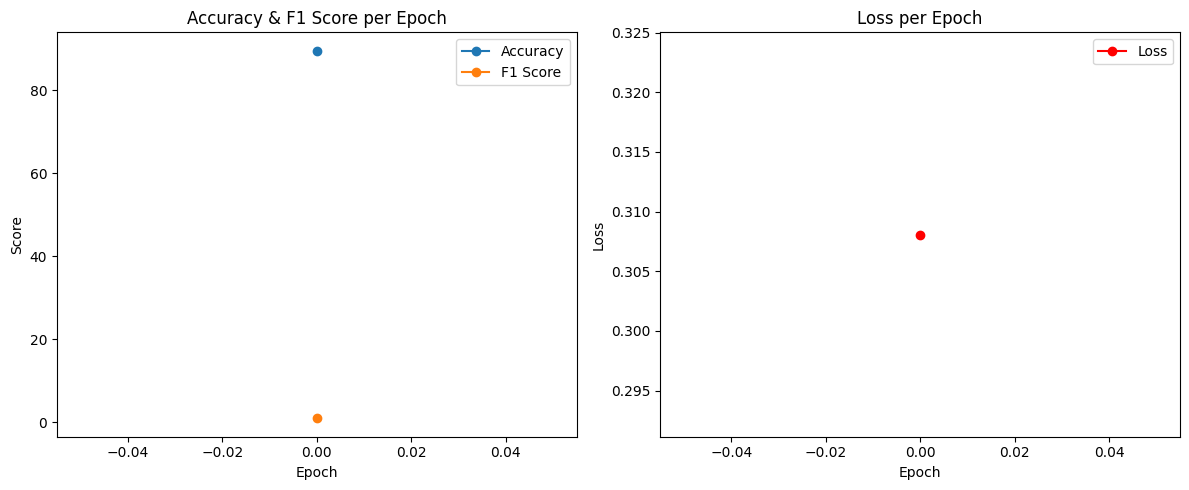

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_accuracies, label="Accuracy", marker='o')
plt.plot(epoch_f1_scores, label="F1 Score", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Accuracy & F1 Score per Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_losses, label="Loss", color='red', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()

plt.tight_layout()
plt.show()



In [18]:

torch.save(model.state_dict(), r"C:\Users\project\Music\project\TuberculosisML\efficientnetv2_tb.pth")
print("✅ Image model weights saved.")

✅ Image model weights saved.


Device: cuda
Original columns: ['fever for two weeks', 'coughing blood', 'sputum mixed with blood', 'night sweats ', 'chest pain', 'back pain in certain parts ', 'shortness of breath', 'weight loss ', 'body feels tired', 'lumps that appear around the armpits and neck', 'cough and phlegm continuously for two weeks to four weeks', 'swollen lymph nodes', 'loss of appetite', 'Prediction']

Normalized columns (first 50): ['fever_for_two_weeks', 'coughing_blood', 'sputum_mixed_with_blood', 'night_sweats', 'chest_pain', 'back_pain_in_certain_parts', 'shortness_of_breath', 'weight_loss', 'body_feels_tired', 'lumps_that_appear_around_the_armpits_and_neck', 'cough_and_phlegm_continuously_for_two_weeks_to_four_weeks', 'swollen_lymph_nodes', 'loss_of_appetite', 'prediction']

Original->Normalized mapping (sample):
  'fever for two weeks' -> 'fever_for_two_weeks'
  'coughing blood' -> 'coughing_blood'
  'sputum mixed with blood' -> 'sputum_mixed_with_blood'
  'night sweats ' -> 'night_sweats'
  'ch

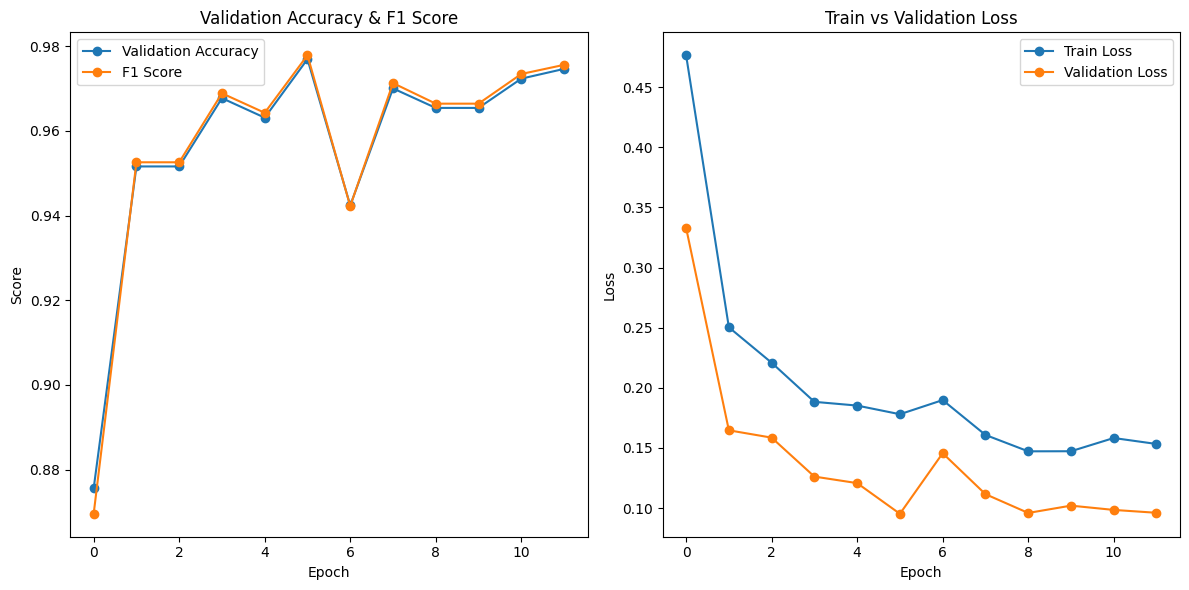

In [19]:
# saint_tabular_auto.py

import os
import re
import difflib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------- CONFIG ----------------
CSV_PATH = r"C:\Users\project\Music\project\TuberculosisML\TB_SymptdataApril2024.csv"
OUTPUT_DIR = r"C:\Users\project\Music\project\TuberculosisML\outputs_tabular"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------- Helpers ----------------
def normalize_colname(name: str) -> str:
    s = name.strip().lower()
    s = re.sub(r"[\/\\\-]+", " ", s)
    s = re.sub(r"[\(\)\[\]\{\},;:.]+", " ", s)
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"__+", "_", s)
    s = s.strip("_")
    return s

def normalize_df_columns(df: pd.DataFrame):
    orig = df.columns.tolist()
    norm = [normalize_colname(c) for c in orig]
    seen = {}
    final = []
    for i, c in enumerate(norm):
        if c in seen:
            seen[c] += 1
            newc = f"{c}_{seen[c]}"
        else:
            seen[c] = 0
            newc = c
        final.append(newc)
    mapping = dict(zip(orig, final))
    df = df.rename(columns=mapping)
    return df, mapping

def suggest_closest(name, candidates, n=3, cutoff=0.5):
    return difflib.get_close_matches(name, candidates, n=n, cutoff=cutoff)

# ---------------- Load & Inspect ----------------
df = pd.read_csv(CSV_PATH)
print("Original columns:", list(df.columns)[:50])
df, mapping = normalize_df_columns(df)
print("\nNormalized columns (first 50):", list(df.columns)[:50])
print("\nOriginal->Normalized mapping (sample):")
for k,v in list(mapping.items())[:20]:
    print(f"  '{k}' -> '{v}'")

# ---------------- Detect Target ----------------
candidate_targets = ["prediction","label","target","tb","tb_label","outcome","diagnosis","y"]
cols = list(df.columns)
found_target = None

for t in candidate_targets:
    if t in cols:
        found_target = t
        break
if found_target is None:
    for t in candidate_targets:
        suggestions = suggest_closest(t, cols, n=1, cutoff=0.6)
        if suggestions:
            found_target = suggestions[0]
            print(f"Auto-suggested target: column '{found_target}' is close to '{t}'")
            break
if found_target is None:
    found_target = cols[-1]
    print(f"Fallback: using last column as target: '{found_target}'")
print("Selected target column:", found_target)

# ---------------- Select Features ----------------
exclude_keywords = {"id", "patient", "patient_id", "filename", "file", "image", "img", found_target}
feature_cols = [c for c in cols if c not in exclude_keywords]
if not feature_cols:
    raise ValueError("No feature columns found.")

print(f"Number of feature columns: {len(feature_cols)}")
print("Feature columns (sample):", feature_cols[:50])

# ---------------- Prepare Data ----------------
X = df[feature_cols].astype(np.float32).values
y = df[found_target].astype(np.int64).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "tab_scaler.pkl"))

# ---------------- Dataset ----------------
class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabDataset(X_train, y_train)
val_ds = TabDataset(X_val, y_val)
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ---------------- SAINT-like Model ----------------
class SAINTLike(nn.Module):
    def __init__(self, num_features, token_dim=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.token_dim = token_dim
        self.feature_projs = nn.ModuleList([nn.Linear(1, token_dim) for _ in range(num_features)])
        self.cls_token = nn.Parameter(torch.randn(1,1,token_dim))
        self.pos_emb = nn.Parameter(torch.randn(1, num_features+1, token_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=token_dim, nhead=n_heads, dim_feedforward=token_dim*4, dropout=dropout, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(token_dim)
        self.head = nn.Sequential(nn.Linear(token_dim, token_dim//2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(token_dim//2, 1))
    def forward(self, x):
        B = x.size(0)
        toks = [self.feature_projs[i](x[:, i].unsqueeze(1)).unsqueeze(1) for i in range(self.num_features)]
        toks = torch.cat(toks, dim=1)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, toks], dim=1)
        tokens = tokens + self.pos_emb[:, :tokens.size(1), :]
        tokens = self.ln(tokens)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        logits = self.head(cls_out).squeeze(1)
        return logits

# ---------------- Training Setup ----------------
model = SAINTLike(num_features=len(feature_cols)).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * Xb.size(0)
    return total_loss / len(loader.dataset)

def eval_model(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            logits = model(Xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.extend(probs)
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)

# ---------------- Training Loop ----------------
EPOCHS = 12
best_loss = 1e9
best_state = None

train_losses, val_losses = [], []
val_accuracies, val_f1s, val_aucs = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model, train_loader)
    val_preds, val_labels = eval_model(model, val_loader)
    val_logits = np.log(val_preds + 1e-9) - np.log(1 - val_preds + 1e-9)
    val_loss = float(criterion(torch.tensor(val_logits), torch.tensor(val_labels, dtype=torch.float32)))
    val_pred_bin = (val_preds >= 0.5).astype(int)

    acc = accuracy_score(val_labels, val_pred_bin)
    f1 = f1_score(val_labels, val_pred_bin)
    prec = precision_score(val_labels, val_pred_bin, zero_division=0)
    rec = recall_score(val_labels, val_pred_bin, zero_division=0)
    try:
        auc = roc_auc_score(val_labels, val_preds)
    except:
        auc = float("nan")

    print(f"Epoch {epoch}/{EPOCHS} | train_loss: {tr_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {acc:.4f} | val_auc: {auc:.4f} | f1: {f1:.4f}")

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    val_f1s.append(f1)
    val_aucs.append(auc)

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, os.path.join(OUTPUT_DIR, "saint_tabular_best.pth"))

torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "saint_tabular_final.pth"))
print("Saved model and scaler to", OUTPUT_DIR)

# ---------------- Final Evaluation ----------------
val_pred_bin = (val_preds >= 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(val_labels, val_pred_bin))

print("Confusion Matrix:")
print(confusion_matrix(val_labels, val_pred_bin))

# ---------------- Plot Metrics ----------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(val_accuracies, label="Validation Accuracy", marker='o')
plt.plot(val_f1s, label="F1 Score", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy & F1 Score")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_metrics.png"))
plt.show()


In [20]:
torch.save(model.state_dict(), "fusion_model.pth")


Predicted probability: 0.5545 | Predicted label: 1


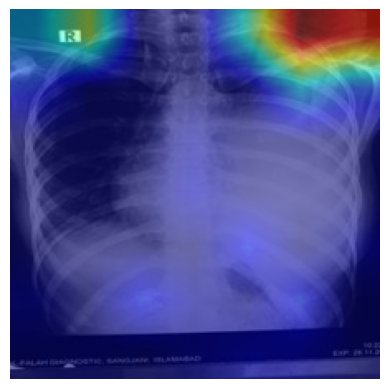

In [29]:
import os
import torch
import torch.nn as nn
import torchvision
import joblib
import numpy as np
from torchvision import transforms
from PIL import Image

# For Grad-CAM++
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------------- Device ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TABULAR_MODEL_PATH = r"C:\Users\project\Music\project\TuberculosisML\outputs_tabular\saint_tabular_best.pth"
IMAGE_MODEL_PATH = r"C:\Users\project\Music\project\TuberculosisML\efficientnetv2_tb.pth"
SCALER_PATH = r"C:\Users\project\Music\project\TuberculosisML\outputs_tabular\tab_scaler.pkl"
IMAGE_PATH = r"C:\Users\project\Music\project\TuberculosisML\Database\Tuberculosis\TB.26.jpg"  # Test image path

# ---------------- Feature count ----------------
NUM_TABULAR_FEATURES = 13  # Must match what the tabular model was trained on

# ---------------- Tabular model (SAINTLike) ----------------
class SAINTLike(nn.Module):
    def __init__(self, num_features, token_dim=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.token_dim = token_dim
        self.feature_projs = nn.ModuleList([nn.Linear(1, token_dim) for _ in range(num_features)])
        self.cls_token = nn.Parameter(torch.randn(1, 1, token_dim))
        self.pos_emb = nn.Parameter(torch.randn(1, num_features + 1, token_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=token_dim, nhead=n_heads, dim_feedforward=token_dim * 4, dropout=dropout, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(token_dim)
        self.head = nn.Sequential(
            nn.Linear(token_dim, token_dim),  # 128 → 128
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        B = x.size(0)
        toks = []
        for i in range(self.num_features):
            col = x[:, i].unsqueeze(1)
            tok = self.feature_projs[i](col)
            toks.append(tok.unsqueeze(1))
        toks = torch.cat(toks, dim=1)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, toks], dim=1)
        tokens = tokens + self.pos_emb[:, :tokens.size(1), :]
        tokens = self.ln(tokens)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        features = self.head(cls_out)
        return features  # shape: [B, 128]

# ---------------- Fusion model ----------------
class FusionModel(nn.Module):
    def __init__(self, tabular_model_path, image_model_path, num_tab_features):
        super().__init__()

        # --- Tabular model ---
        self.tabular_model = SAINTLike(num_features=num_tab_features)
        tab_state_dict = torch.load(tabular_model_path, map_location=DEVICE)
        tab_filtered_state_dict = {k: v for k, v in tab_state_dict.items() if not k.startswith('head.')}
        self.tabular_model.load_state_dict(tab_filtered_state_dict, strict=False)
        self.tabular_model.to(DEVICE)
        self.tabular_model.eval()

        # --- Image model ---
        self.image_model = torchvision.models.efficientnet_v2_s(weights=None)
        self.image_model.classifier = nn.Identity()
        img_state_dict = torch.load(image_model_path, map_location=DEVICE)
        img_filtered_state_dict = {k: v for k, v in img_state_dict.items() if not k.startswith('classifier.')}
        self.image_model.load_state_dict(img_filtered_state_dict, strict=False)
        self.image_model.to(DEVICE)
        self.image_model.eval()

        self.image_fc = nn.Sequential(
            nn.Linear(1280, 128),
            nn.ReLU()
        )

        # --- Final classifier ---
        self.classifier = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, tabular_input, image_input):
        tab_feats = self.tabular_model(tabular_input)        # [B, 128]
        img_feats = self.image_model(image_input)            # [B, 1280]
        img_feats = self.image_fc(img_feats)                 # [B, 128]
        combined = torch.cat([tab_feats, img_feats], dim=1)  # [B, 256]
        out = self.classifier(combined)                      # [B, 1]
        return out.squeeze(1)

# ---------------- Image preprocessing ----------------
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def load_and_preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_for_overlay = np.array(img_resized).astype(np.float32) / 255.0  # normalized for visualization
    image_tensor = image_transform(img_resized).unsqueeze(0).to(DEVICE)
    return image_tensor, img_for_overlay

# ---------------- Tabular preprocessing ----------------
scaler = joblib.load(SCALER_PATH)

def preprocess_tabular(row_np):
    scaled = scaler.transform([row_np])  # shape: [1, num_features]
    return torch.tensor(scaled, dtype=torch.float32).to(DEVICE)

# ---------------- Grad-CAM++ generation ----------------
def generate_gradcampp(image_tensor, model, target_layer):
    cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor, targets=None)  # shape: [B, H, W]
    return grayscale_cam

# ---------------- Load model ----------------
model = FusionModel(TABULAR_MODEL_PATH, IMAGE_MODEL_PATH, NUM_TABULAR_FEATURES).to(DEVICE)
model.eval()

# ---------------- Run inference and explain ----------------
def run_inference_and_explain(image_path, tabular_input_list):
    # Preprocess inputs
    image_tensor, img_for_overlay = load_and_preprocess_image(image_path)
    tabular_np = np.array(tabular_input_list)
    tabular_tensor = preprocess_tabular(tabular_np)

    # Forward pass
    with torch.no_grad():
        output = model(tabular_tensor, image_tensor)
        prob = torch.sigmoid(output)
        prediction = (prob >= 0.5).float()

    print(f"Predicted probability: {prob.item():.4f} | Predicted label: {int(prediction.item())}")

    # Grad-CAM++ explainability
    target_layer = model.image_model.features[-1]
    cam_mask = generate_gradcampp(image_tensor, model.image_model, target_layer)
    grayscale = cam_mask[0]  # shape: (224, 224)

    # Overlay Grad-CAM++ mask on image
    visualization = show_cam_on_image(img_for_overlay, grayscale, use_rgb=True)

    # Display result (requires matplotlib)
    import matplotlib.pyplot as plt
    plt.imshow(visualization)
    plt.axis('off')
    plt.show()

# ---------------- Example usage ----------------
if __name__ == "__main__":
    sample_tabular_input = [52, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  # Replace with actual tabular data
    run_inference_and_explain(IMAGE_PATH, sample_tabular_input)


In [ ]:
tabular_sample_np = np.array([
    45,  # Age
    1,   # Gender (1 = Male, 0 = Female)
    1,   # Cough
    0,   # Fever
    0,   # Fatigue
    1,   # Weight loss
    0,   # Night sweats
    1,   # Chest pain
    0,   # Hemoptysis
    1,   # Shortness of breath
    0,   # HIV status
    1,   # Smoker
    0    # Diabetes
])